In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('creditcard.csv.zip')

In [5]:
# 5 rows and 31columns of the dataset
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
df.duplicated().sum()
# it means the dataset has 1081 duplicate rows which we can drop

np.int64(1081)

In [10]:
#checking the genuine and fraud transactions
df['Class'].value_counts()
# 0 = genuine transaction : 284315 transactions
# 1 = fraud transaction : 492 transactions

Class
0    284315
1       492
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

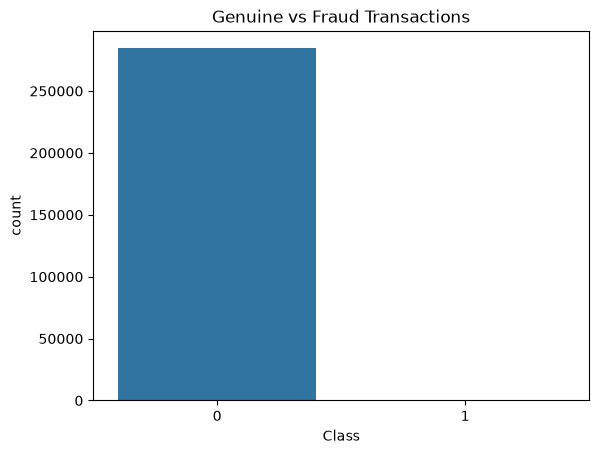

In [11]:
# we will viualize the balance
#lets make a simple chart for seeing the difference
sns.countplot(x='Class',data=df)
plt.title("Genuine vs Fraud Transactions")
plt.show

In [12]:

# dataset size = 284,807 * 31
# missing values = 0
# duplicate rows = 1,081
#genuine transactions = 284,315
#fraud transactions = 492
#fraud data is highly imbalanced

In [13]:
df["Amount"].describe()
# checking transaction amount

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [14]:
# count - no. of transactions
# mean - average transaction amount
#std - how much amount vary
# min - smallest amount
# 25% - 25% of transactions are below this amount
#50% - median amoount
# 75% - third-quarter value
#max - largest amount

In [15]:
df.groupby("Class")["Amount"].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

In [16]:
# class 0 (genuine) : average amount = 88.29
# class 1 (fraud) : average amount = 122.21
# in this dataset, fraudlent transactions have a higher average transaction amount then genuin ones

In [17]:
# seperating input x and target y 
X = df.drop("Class" , axis=1)
y = df["Class"]

In [18]:
X.shape,y.shape

((284807, 30), (284807,))

In [19]:
#splitting into training and testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2, 
    random_state=42,
    stratify=y

)


In [28]:
print("Trainig data :",X_train.shape)
print("Testing data :",X_test.shape)

Trainig data : (227845, 30)
Testing data : (56962, 30)


In [20]:
y_train.value_counts()
# it is showing how many transactions are there in training data 0-genuine , 1-fraud

Class
0    227451
1       394
Name: count, dtype: int64

In [31]:
from sklearn.tree import DecisionTreeClassifier     #decision tree model

model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)
#best algorithm

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_f

In [32]:
y_pred= model.predict(X_test)     # prediction

In [ ]:
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9989291106351603
Accuracy percentage: 99.89291106351604 %


In [ ]:
# we have only 492 fraud transactions compared with 284,315 genuine ones , so accurcy can be misleading for an imbalanced dataset

In [33]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56830    34]
 [   27    71]]


In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.6761904761904762
Recall: 0.7244897959183674
F1-Score: 0.6995073891625616


In [ ]:
# PRECISION - out of transactions predicted as fraud, how many were actually  .
#RECALL - out of actual fraud transactions, how many were correctly predicted as fraud .
#F1-Score - combined measure of precesion and recall.
# for this project , recall is especially important because mising an actual fraud transaction (false negative) can be a serious problem.

In [44]:
# final result
print("Decision Tree Results")
print("---------------------")
print("Accuracy:",  accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Decision Tree Results
---------------------
Accuracy: 0.9989291106351603
Precision: 0.6761904761904762
Recall   : 0.7244897959183674
F1-Score : 0.6995073891625616


In [ ]:
# we save the train decision tree model so we can use it later.

import joblib
joblib.dump(model, "decision_tree_model.pkl")
print("Model saved successfully!")

Model saved successfully!


Conclusion

In this project, we used Machine Learning to detect fraudulent credit card transactions.

We performed data preprocessing, divided the data into training and testing sets, trained a Decision Tree model, and evaluated its performance using:

- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-Score

The Decision Tree model was successfully trained and saved for future use.

This project helped me understand the basic Machine Learning workflow and how classification algorithms can be used for fraud detection.